# Data Preprocessing Pipeline: Corruption Perceptions Index

This notebook transforms raw JSON data into a structured and normalized format.

**Input:** Raw JSON dataset  
**Processing:** Type casting, column standardization, missing value handling, validation  
**Output:** Cleaned JSON dataset prepared for database upload

## Data description

The CPI uses a scale from 0 to 100, where 0 means highly corrupt and 100 means very clean

In [115]:
# Importing libraries
import pandas as pd
import matplotlib.pyplot as plt

In [117]:
df = pd.read_json('raw_data\cpi_raw.json') # Check the directory where raw data file is stored

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\Honor\AppData\Local\Temp\ipykernel_23200\1845462159.py:1: SyntaxWarning: invalid escape sequence '\c'
  df = pd.read_json('raw_data\cpi_raw.json') # Check the directory where raw data file is stored


In [119]:
# glancing at the data
df.head()

,country,iso3,region,year,score,rank,sources,standardError,lowerCi,upperCi
0,Afghanistan,AFG,AP,2012,8,174,3,3.30,2,13
1,Afghanistan,AFG,AP,2013,8,175,3,3.30,3,13
2,Afghanistan,AFG,AP,2014,12,172,4,1.29,10,14
3,Afghanistan,AFG,AP,2015,11,166,4,3.49,5,17
4,Afghanistan,AFG,AP,2016,15,169,5,1.74,12,17


In [121]:
print(df['year'].min())
print(df['year'].max())

2012
2025


In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2494 entries, 0 to 2493
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   country        2494 non-null   object 
 1   iso3           2494 non-null   object 
 2   region         2494 non-null   object 
 3   year           2494 non-null   int64  
 4   score          2494 non-null   int64  
 5   rank           2494 non-null   int64  
 6   sources        2494 non-null   int64  
 7   standardError  2494 non-null   float64
 8   lowerCi        2494 non-null   int64  
 9   upperCi        2494 non-null   int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 195.0+ KB


In [125]:
df.describe()

,year,score,rank,sources,standardError,lowerCi,upperCi
count,2494.000000,2494.000000,2494.000000,2494.000000,2494.000000,2494.000000,2494.000000
mean,2018.552125,42.985164,88.208901,6.783480,2.780245,38.424218,47.544507
std,4.030307,19.208177,51.137875,1.837467,1.521753,19.390856,19.357247
min,2012.000000,8.000000,1.000000,3.000000,0.370000,2.000000,11.000000
25%,2015.000000,29.000000,44.000000,6.000000,1.750000,24.000000,33.000000
50%,2019.000000,38.000000,87.000000,7.000000,2.400000,34.000000,43.000000
75%,2022.000000,56.000000,131.000000,8.000000,3.347500,51.000000,62.000000
max,2025.000000,92.000000,181.000000,10.000000,12.810000,89.000000,95.000000


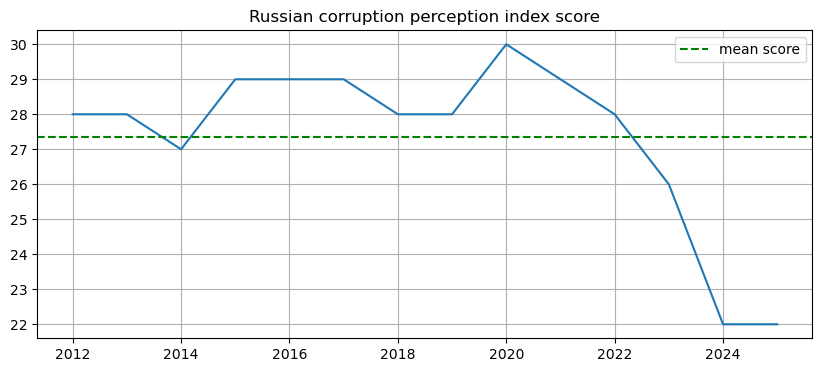

In [127]:
# visualizing some data
rus = df[df['country']=='Russia']
plt.figure(figsize=(10,4))
plt.grid()
plt.plot(rus['year'], rus['score'])
plt.title('Russian corruption perception index score')
plt.axhline(rus['score'].mean(), color = 'g', linestyle = '--', label = 'mean score')
plt.legend()
plt.show()

In [129]:
df.groupby('year')['country'].count()

year
2012    176
2013    177
2014    175
2015    168
2016    176
2017    180
2018    180
2019    180
2020    180
2021    180
2022    180
2023    180
2024    180
2025    182
Name: country, dtype: int64

In [131]:
# renaming a column and casting it to string
df['country_code'] = df['iso3'].astype("string")
df.drop(columns=["iso3"], inplace = True)

In [133]:
df["country_year"] = (df["country_code"] + df["year"].astype(str))

In [135]:
df.head()

,country,region,year,score,rank,sources,standardError,lowerCi,upperCi,country_code,country_year
0,Afghanistan,AP,2012,8,174,3,3.30,2,13,AFG,AFG2012
1,Afghanistan,AP,2013,8,175,3,3.30,3,13,AFG,AFG2013
2,Afghanistan,AP,2014,12,172,4,1.29,10,14,AFG,AFG2014
3,Afghanistan,AP,2015,11,166,4,3.49,5,17,AFG,AFG2015
4,Afghanistan,AP,2016,15,169,5,1.74,12,17,AFG,AFG2016


In [137]:
# pivoting the table so that only unique country names are in the rows
df_wide = df.pivot(index = 'country', columns = 'year', values = 'score')
df_wide.reset_index(inplace=True)

In [139]:
# adding country code: taking them from original table and merge with wide version using country_name as a key
country_code_table = df[['country', 'country_code']].drop_duplicates() 
df_wide = df_wide.merge(country_code_table, on='country', how='left')

In [143]:
country_code_table.head()

,country,country_code
0,Afghanistan,AFG
14,Albania,ALB
28,Algeria,DZA
42,Angola,AGO
56,Argentina,ARG


In [147]:
df_wide[df_wide["country_code"].isna()]['country'].unique() # mapped successfully

array([], dtype=object)

In [149]:
df_wide.head()

,country,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,country_code
0,Afghanistan,8.0,8.0,12.0,11.0,15.0,15.0,16.0,16.0,19.0,16.0,24.0,20.0,17.0,16.0,AFG
1,Albania,33.0,31.0,33.0,36.0,39.0,38.0,36.0,35.0,36.0,35.0,36.0,37.0,42.0,39.0,ALB
2,Algeria,34.0,36.0,36.0,36.0,34.0,33.0,35.0,35.0,36.0,33.0,33.0,36.0,34.0,34.0,DZA
3,Angola,22.0,23.0,19.0,15.0,18.0,19.0,19.0,26.0,27.0,29.0,33.0,33.0,32.0,32.0,AGO
4,Argentina,35.0,34.0,34.0,32.0,36.0,39.0,40.0,45.0,42.0,38.0,38.0,37.0,37.0,36.0,ARG


## Saving preprocessed datasets

In [67]:
df.to_json(
    "processed_data/corruption_perception_clean.json",
    orient="records",
    indent=2,
    force_ascii=False
)

In [151]:
df_wide.to_json(
    "processed_data/corruption_perception_wide_clean.json",
    orient="records",
    indent=2,
    force_ascii=False
)